WEEK 4:

The Cleaning Sprint : Handling Missing Values (Imputation
strategies) and Outlier Detection (Boxplots/Z-score)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

These libraries are imported to perform data analysis and visualization.

Pandas – used for loading and manipulating the dataset.

NumPy – used for numerical computations.

Matplotlib – used to create graphs and visualizations.

Seaborn – used for advanced statistical visualizations like heatmaps.

SciPy (stats) – used for statistical operations such as outlier detection.

In [10]:
df = pd.read_csv("/content/retail_store_sales.csv")

This line reads the CSV file containing the retail store transaction data and loads it into a Pandas DataFrame called df, which allows us to analyze and manipulate the dataset.

In [11]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

These lines convert the specified columns into numeric data types.
If any invalid value exists, errors='coerce' converts it into NaN, which can later be handled during data cleaning.

In [12]:
df['Price Per Unit'].fillna(df['Price Per Unit'].mean(), inplace=True)
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
df['Total Spent'].fillna(df['Total Spent'].mean(), inplace=True)
df['Item'].fillna(df['Item'].mode()[0], inplace=True)
df['Discount Applied'].fillna('False', inplace=True)

/tmp/ipykernel_4675/3902087779.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price Per Unit'].fillna(df['Price Per Unit'].mean(), inplace=True)
/tmp/ipykernel_4675/3902087779.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

Missing values in the dataset are handled using appropriate strategies:

Mean is used for numerical columns like price and total spending.
Median is used for quantity to avoid the effect of extreme values.
Mode is used for categorical data such as item names.
Missing discount values are replaced with False, assuming no discount was applied.

This step ensures the dataset is clean and ready for analysis.

# Univariate Analysis:
Univariate analysis is a statistical method used to examine and understand a single variable in a dataset. The main purpose of univariate analysis is to describe the characteristics, distribution, and patterns of that variable without considering its relationship with other variables.

In univariate analysis, the focus is on summarizing the data and identifying important properties such as the frequency of values, central tendency (mean, median, mode), and variability (range, variance, standard deviation). This helps researchers and analysts understand how the data is distributed and whether there are any unusual patterns or outliers.

Various graphical techniques are commonly used in univariate analysis to visualize the distribution of the variable. Some of the most commonly used graphs include histograms, bar charts, box plots, pie charts, and violin plots. These visualizations make it easier to interpret the data and identify trends or patterns.

In the context of retail store data, univariate analysis can be used to study variables such as quantity purchased, total spending, payment methods, and sales location individually. For example, analyzing the distribution of quantity purchased helps understand how many items customers typically buy in a transaction, while examining payment methods helps identify the most commonly used payment options.

Overall, univariate analysis is an important first step in exploratory data analysis (EDA) because it provides a basic understanding of each variable before performing more complex analyses such as bivariate or multivariate analysis

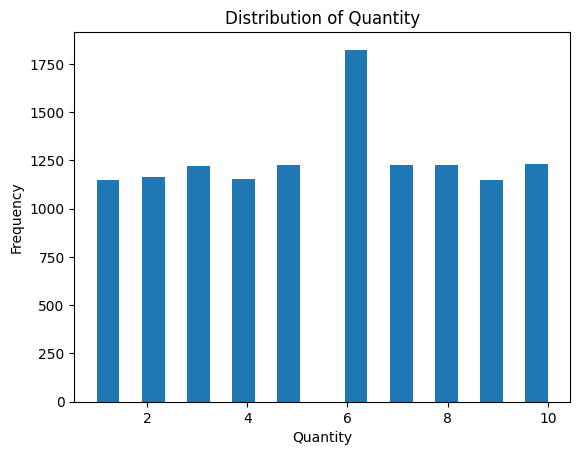

In [ ]:
plt.hist(df['Quantity'], bins=20)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

This histogram shows the distribution of the number of items purchased in each transaction. It helps understand the most common purchase quantities.

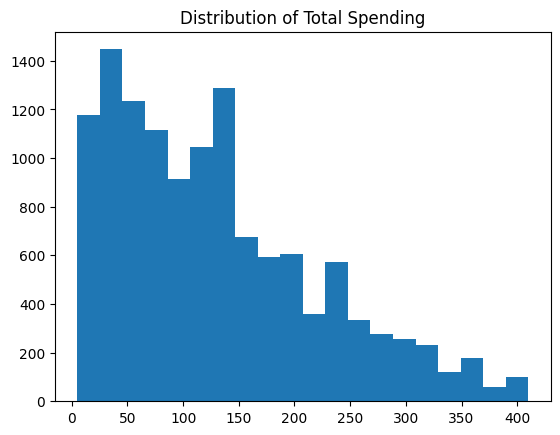

In [ ]:
plt.hist(df['Total Spent'], bins=20)
plt.title("Distribution of Total Spending")
plt.show()

This histogram visualizes how much customers spend per transaction. It helps identify spending patterns among customers.

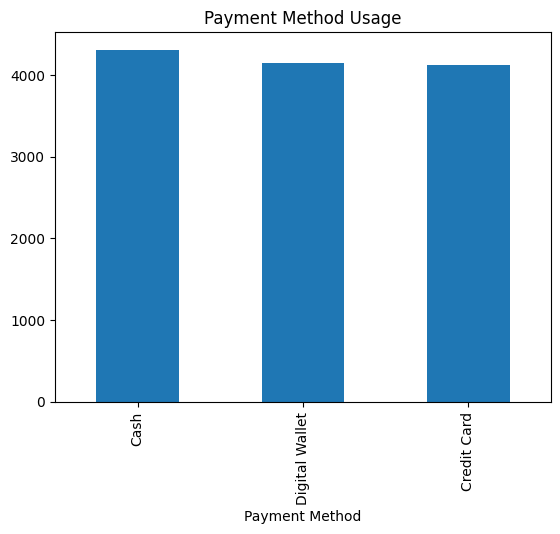

In [ ]:
df['Payment Method'].value_counts().plot(kind='bar')
plt.title("Payment Method Usage")
plt.show()

This bar chart shows how frequently each payment method is used by customers, helping understand customer payment preferences.

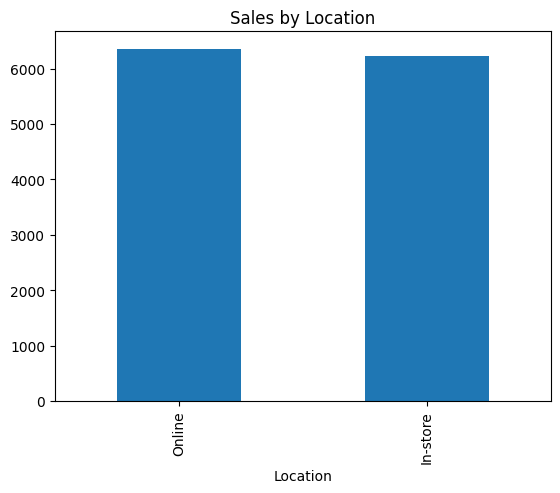

In [ ]:
df['Location'].value_counts().plot(kind='bar')
plt.title("Sales by Location")
plt.show()

This graph compares the number of purchases made online and in-store, providing insight into where customers prefer to shop.

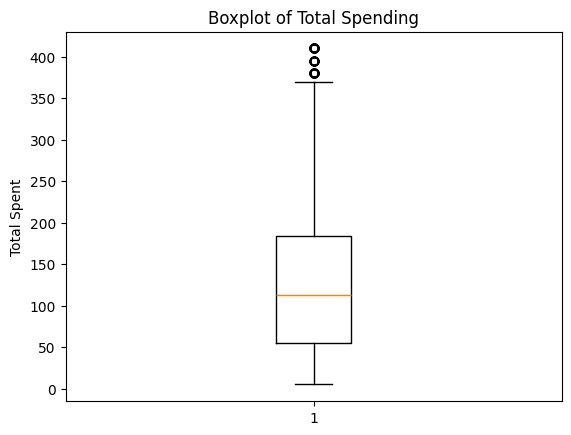

In [ ]:
plt.boxplot(df['Total Spent'])
plt.title("Boxplot of Total Spending")
plt.ylabel("Total Spent")
plt.show()

This boxplot visualizes the distribution of total spending and helps identify any extreme values or outliers in customer transactions.

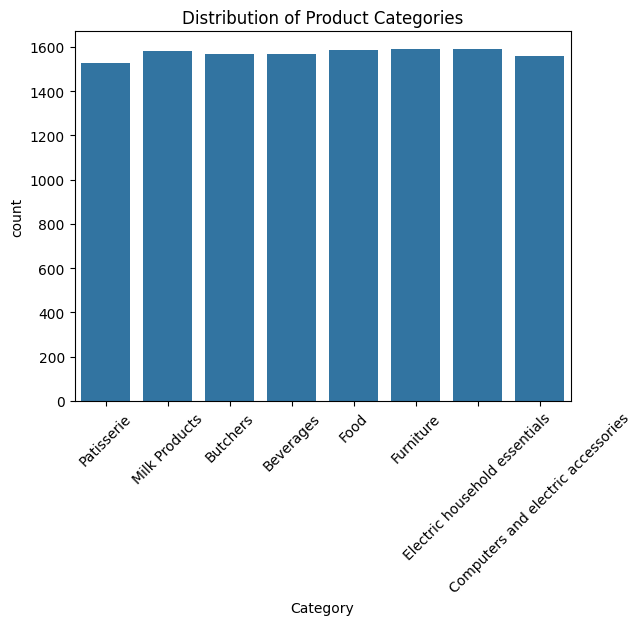

In [ ]:
sns.countplot(x='Category', data=df)
plt.title("Distribution of Product Categories")
plt.xticks(rotation=45)
plt.show()

This graph shows how frequently each product category appears in the dataset, helping understand which types of products are purchased most often.

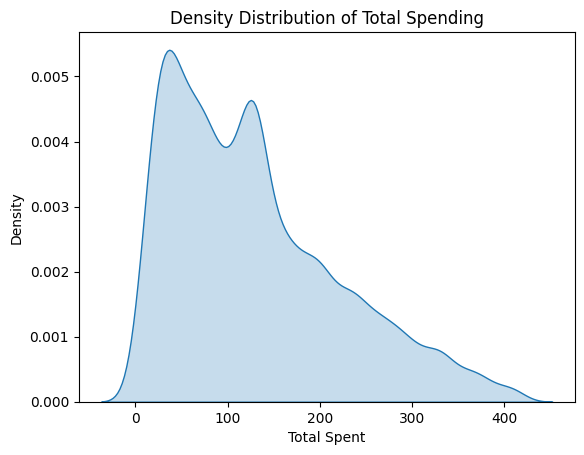

In [ ]:
sns.kdeplot(df['Total Spent'], fill=True)
plt.title("Density Distribution of Total Spending")
plt.show()

The density plot represents the distribution of total spending and helps understand how customer spending is spread across different values.

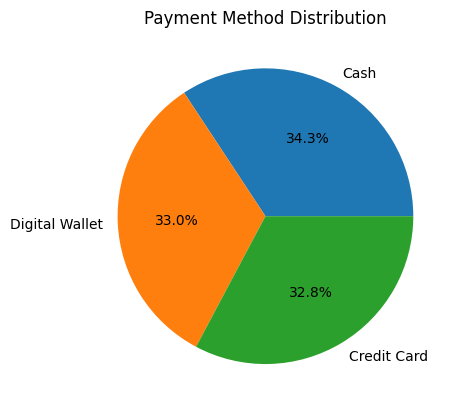

In [ ]:
df['Payment Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

This pie chart shows the proportion of transactions completed using different payment methods.

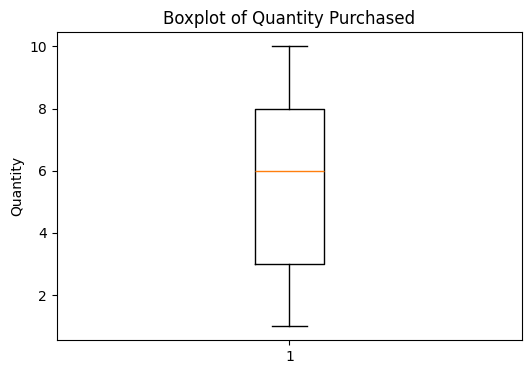

In [ ]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Quantity'])
plt.title("Boxplot of Quantity Purchased")
plt.ylabel("Quantity")
plt.show()

This boxplot represents the distribution of the quantity of items purchased per transaction. It highlights the median purchase quantity, the spread of the data, and any potential outliers. The visualization helps identify whether customers generally purchase similar quantities or if extreme purchase behaviors exist.

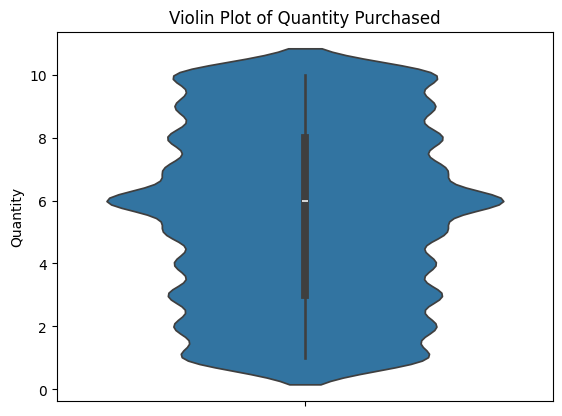

In [ ]:
sns.violinplot(y=df['Quantity'])
plt.title("Violin Plot of Quantity Purchased")
plt.show()

The violin plot is used to visualize the distribution of the quantity of items purchased in the dataset. It combines features of both a boxplot and a density plot, allowing us to see the spread and shape of the data simultaneously.

In this graph, the width of the violin represents the density of data points at different quantity levels. Wider sections indicate that more transactions occur at that quantity level, while narrower sections show fewer observations.

# Bivariate Analysis

Bivariate analysis is the statistical analysis of two variables at the same time to understand the relationship or association between them.

It helps determine whether changes in one variable are related to changes in another variable.

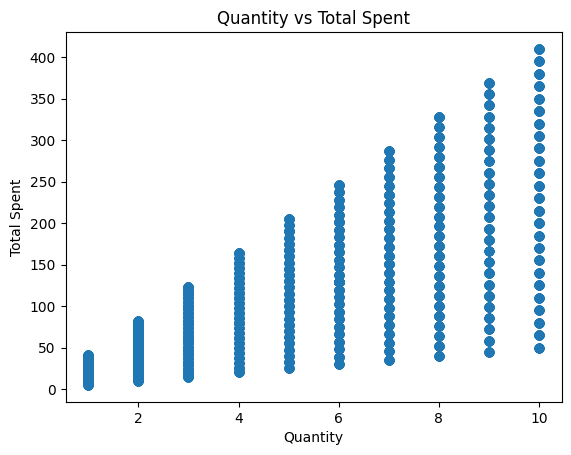

In [ ]:
plt.scatter(df['Quantity'], df['Total Spent'])
plt.title("Quantity vs Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")
plt.show()

This scatter plot shows the relationship between the number of items purchased and the total spending amount. It helps determine whether spending increases as purchase quantity increases.

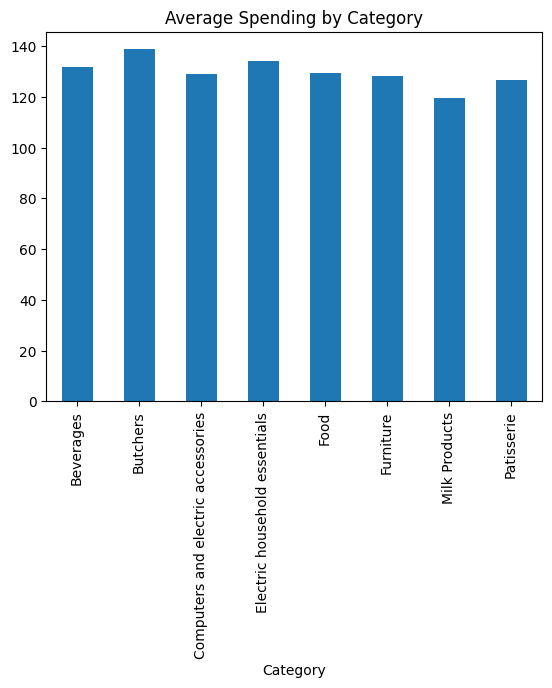

In [ ]:
df.groupby('Category')['Total Spent'].mean().plot(kind='bar')
plt.title("Average Spending by Category")
plt.show()

This bar chart compares the average spending across different product categories, helping identify which categories generate higher revenue.

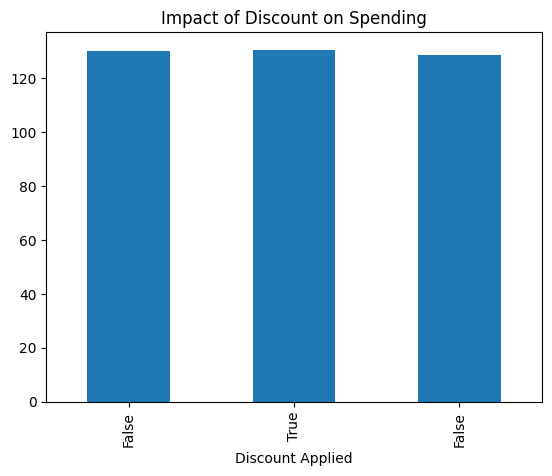

In [ ]:
df.groupby('Discount Applied')['Total Spent'].mean().plot(kind='bar')
plt.title("Impact of Discount on Spending")
plt.show()

This graph analyzes how discounts affect customer spending behavior by comparing average spending with and without discounts

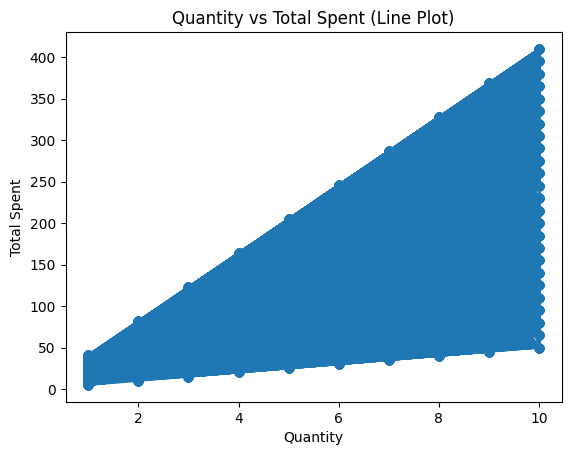

In [ ]:
plt.plot(df['Quantity'], df['Total Spent'], marker='o')
plt.title("Quantity vs Total Spent (Line Plot)")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")
plt.show()

This line plot shows how total spending changes as the quantity of items purchased increases.

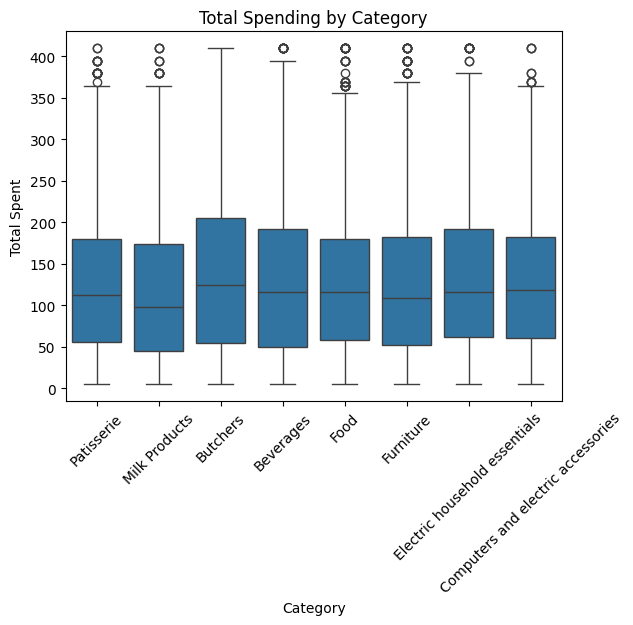

In [ ]:
sns.boxplot(x='Category', y='Total Spent', data=df)
plt.title("Total Spending by Category")
plt.xticks(rotation=45)
plt.show()

This graph compares the distribution of total spending across different product categories.

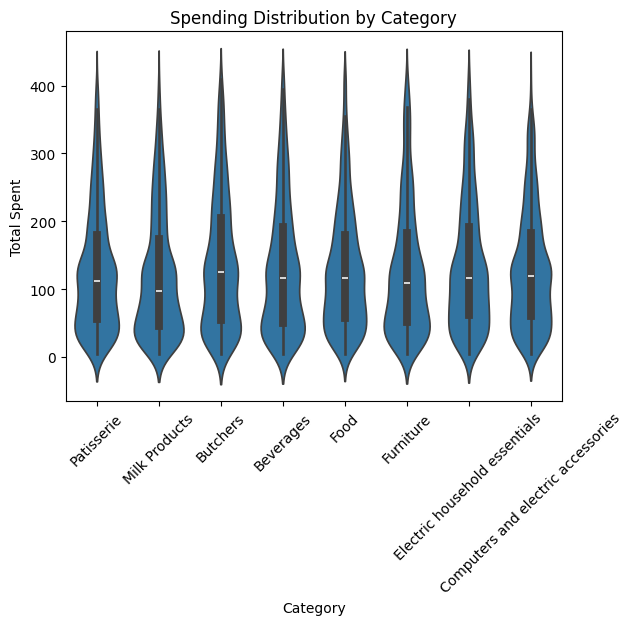

In [ ]:
sns.violinplot(x='Category', y='Total Spent', data=df)
plt.title("Spending Distribution by Category")
plt.xticks(rotation=45)
plt.show()

The violin plot shows the density and distribution of total spending for each product category.

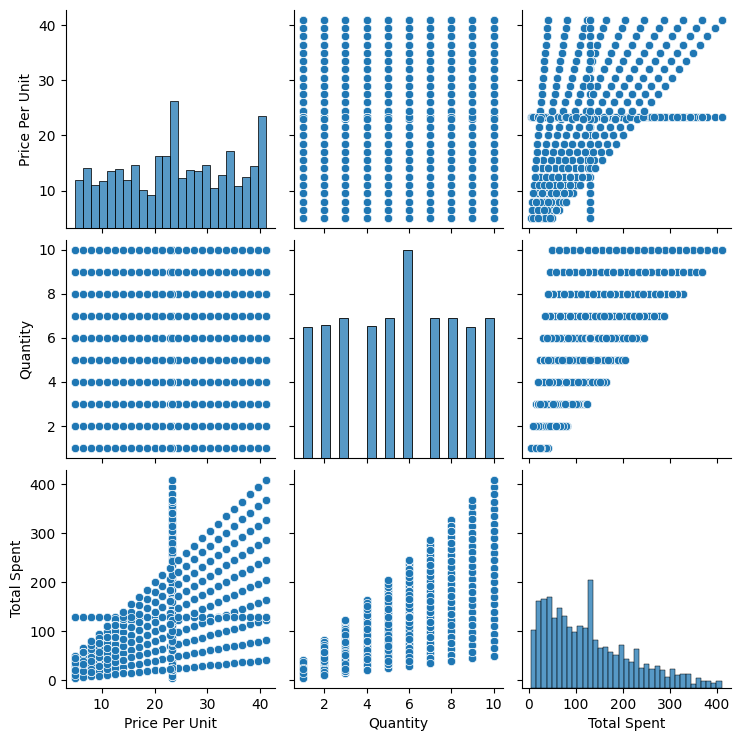

In [ ]:
sns.pairplot(df[['Price Per Unit','Quantity','Total Spent']])
plt.show()

The pair plot shows relationships between multiple numerical variables at once

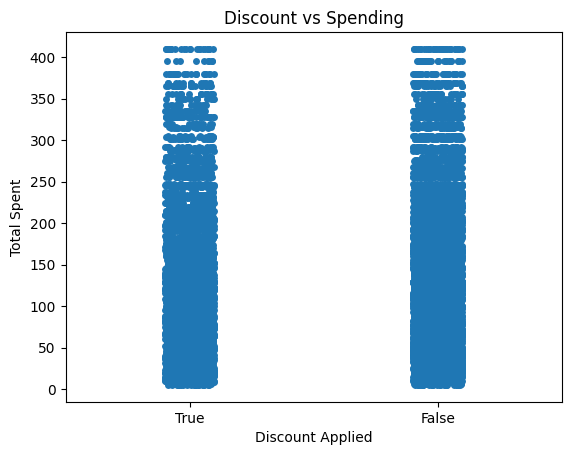

In [ ]:
sns.stripplot(x='Discount Applied', y='Total Spent', data=df)
plt.title("Discount vs Spending")
plt.show()

This plot displays individual transaction spending values grouped by whether a discount was applied

# Multivariate Analysis:

Multivariate analysis is a statistical technique used to analyze and understand the relationship between three or more variables simultaneously in a dataset. Unlike univariate analysis, which studies one variable, and bivariate analysis, which examines the relationship between two variables, multivariate analysis explores how multiple variables interact with each other at the same time.

The main purpose of multivariate analysis is to identify patterns, relationships, and dependencies among several variables and to understand how these variables collectively influence a particular outcome. This type of analysis is especially useful when dealing with complex datasets where multiple factors affect the results.

In multivariate analysis, various statistical and visualization techniques are used to examine these relationships. Some commonly used methods include correlation matrices, heatmaps, pair plots, regression analysis, and dimensionality reduction techniques. These tools help visualize how variables are related and whether the relationships are strong, weak, positive, or negative.

For example, in a retail store sales dataset, multivariate analysis can be used to study how price per unit, quantity purchased, and total spending interact with each other. By analyzing these variables together, we can determine how changes in one variable may influence the others and how they collectively affect overall sales performance.

Overall, multivariate analysis provides a deeper understanding of the dataset by considering multiple variables at the same time. It helps uncover hidden relationships and patterns that may not be visible when analyzing variables individually or in pairs. This makes it an important step in exploratory data analysis (EDA) and supports better decision-making in areas such as business analytics, customer behavior analysis, and predictive modeling.

In [ ]:
numeric_df = df[['Price Per Unit', 'Quantity', 'Total Spent']]
corr = numeric_df.corr()

These lines select numerical columns and compute the correlation matrix, which measures how strongly variables are related to each other.

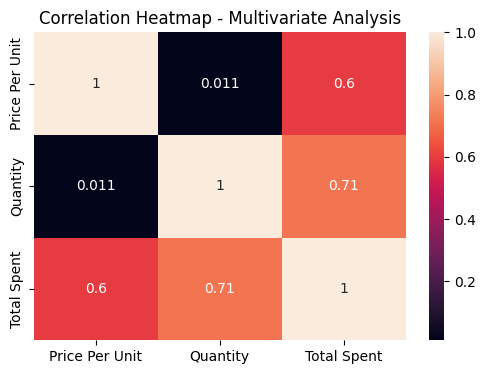

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap - Multivariate Analysis")
plt.show()

This heatmap visualizes the correlation between numerical variables such as price, quantity, and total spending. Stronger correlations indicate stronger relationships between variables.

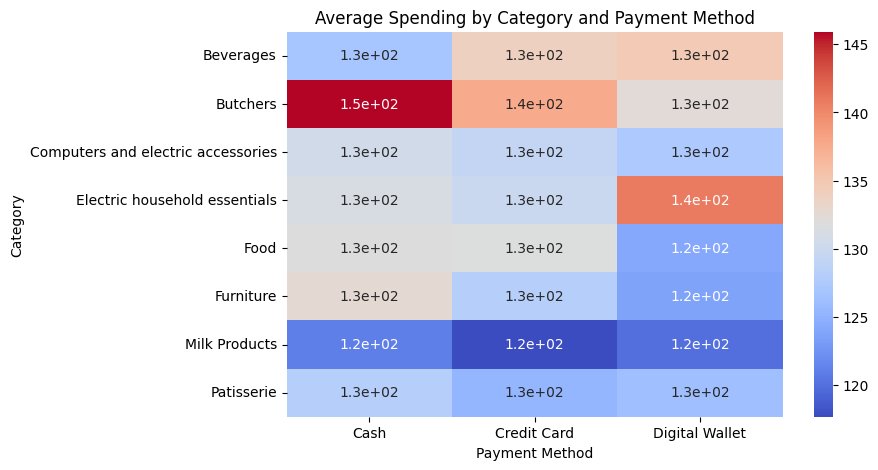

In [ ]:
pivot_table = pd.pivot_table(
    df,
    values='Total Spent',
    index='Category',
    columns='Payment Method',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title("Average Spending by Category and Payment Method")
plt.show()

It shows:

Which payment methods are used more in each category
Average spending behavior across categories

Description:

This heatmap visualizes the relationship between product categories and payment methods based on average spending. It helps identify which payment methods are commonly used for different product categories.

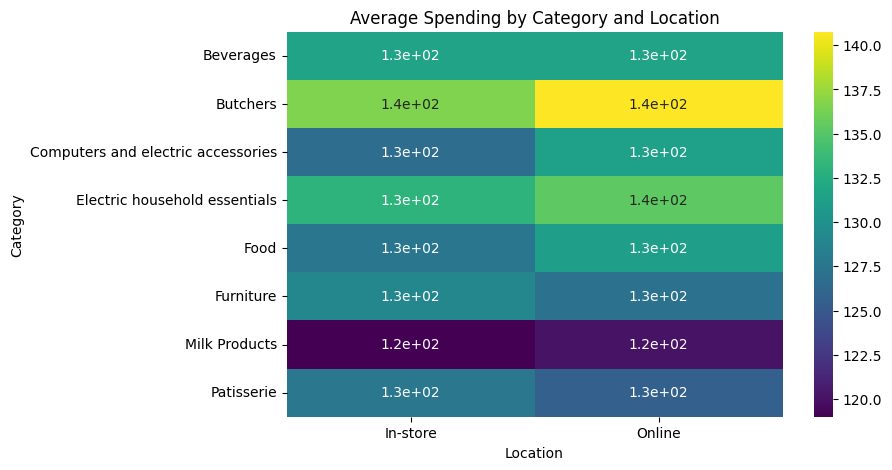

In [13]:
pivot_table = pd.pivot_table(
    df,
    values='Total Spent',
    index='Category',
    columns='Location',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, annot=True, cmap='viridis')
plt.title("Average Spending by Category and Location")
plt.show()

What it shows:

Whether customers spend more online or in-store
Which categories perform better in each location

Description:

This heatmap illustrates the relationship between product categories and purchase locations. It helps analyze how customer spending varies between online and in-store transactions across different product categories.